In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

In [3]:
! head "testGammaEst_result/result_0304-21:10:26.dat"

#PFSA=/home/yhuang10/D3M/zutil_/cfgfiles/PFSA_M2_7.cfg,XPFSA=/home/yhuang10/D3M/zutil_/cfgfiles/XPFSA_2_4_3.cfg,sequence length=5000,depth for estimating gamma=4,numbers of runs=200,data generation time=0.070000,xg time=196.180000,est time=0.070000
xg,est
0.0818618,0.0736818
0.0868273,0.0908664
0.0881524,0.0890149
0.0733902,0.0965498
0.0693061,0.0882826
0.0392417,0.0858655
0.0705594,0.0876842
0.0920053,0.0779085


In [4]:
df = pd.read_csv('testGammaEst_result/result_0304-21:10:26.dat', comment='#')
df.describe()

,xg,est
count,200.000000,200.000000
mean,0.068054,0.085424
std,0.019197,0.007015
min,0.000090,0.066900
25%,0.060935,0.081290
50%,0.070611,0.085003
75%,0.082044,0.090051
max,0.101005,0.109832


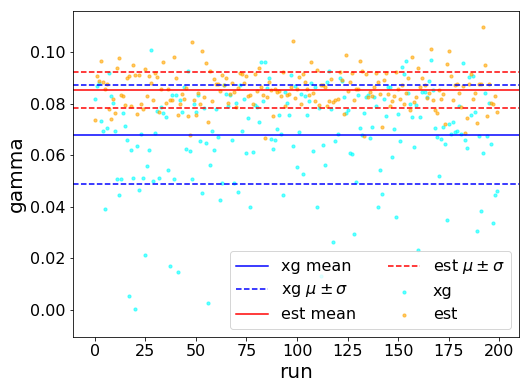

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(df)), df.xg, color='cyan', label='xg', s=10, alpha=.6)
plt.scatter(range(len(df)), df.est, color='orange', label='est', s=10, alpha=.6)

ax = plt.gca()
ax.axhline(df.xg.mean(), color='blue', label='xg mean')
ax.axhline(df.xg.mean() - df.xg.std(), ls='--', color='blue', label='xg $\mu\pm\sigma$')
ax.axhline(df.xg.mean() + df.xg.std(), ls='--', color='blue')

ax.axhline(df.est.mean(), color='red', label='est mean')
ax.axhline(df.est.mean() - df.est.std(), ls='--', color='red', label='est $\mu\pm\sigma$')
ax.axhline(df.est.mean() + df.est.std(), ls='--', color='red')

ax.legend(fontsize=16, ncol=2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('run', fontsize=20)
plt.ylabel('gamma', fontsize=20)

plt.show()

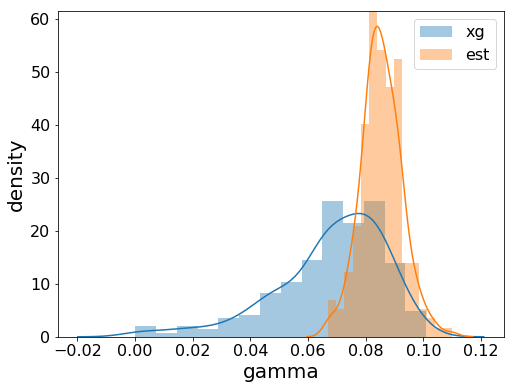

In [6]:
plt.figure(figsize=(8, 6))

ax = sns.distplot(df.xg, label='xg')
# ax.axvline(df.xg.mean(), color='blue', label='xg $\mu$')
# ax.axvline(df.xg.mean() - df.xg.std(), ls='--', color='blue', label='xg $\mu\pm\sigma$')
# ax.axvline(df.xg.mean() + df.xg.std(), ls='--', color='blue')

sns.distplot(df.est, label='est')
# ax.axvline(df.est.mean(), color='red', label='est $\mu$')
# ax.axvline(df.est.mean() - df.est.std(), ls='--', color='red', label='est $\mu\pm\sigma$')
# ax.axvline(df.est.mean() + df.est.std(), ls='--', color='red')

ax.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('gamma', fontsize=20)
plt.ylabel('density', fontsize=20)
# plt.xlim(-0.01, .1)

plt.show()

All time are for 500 rounds
time of data generation = .19 sec
time of xg with rerun 10 = 1002.46 sec (gamma file twoGamma_rerun=10)
time of xg with rerun 10 and no get_norm = 490.78 sec (gamma file twoGamma_rerun=10_noGetNorm)
time of est with rerun 1 = .30 sec - .19 sec = .11 sec (consistent, so use either one)

Conclusion: the gamma generated by genESeSS_x is very unstable.  

In [9]:
! ls testGammaEst_result/

result_0304-21:06:42.dat	   testGammaEst_Cor_example
result_0304-21:10:26.dat	   testGammaEst_example
result_Cor0306-20:37:54.dat	   twoGammas_another.dat
result_Cor0306-20:41:06.dat	   twoGammas_rerun=10.dat
result_Cor0306-21:13:41.dat	   twoGammas_rerun=10_noGetNorm_3_3_oppo.dat
resultCor_random0308-17:41:05.dat  twoGammas_rerun=10_noGetNorm.dat
testGammaEst_Cor_1_example


In [12]:
cor = pd.read_csv("testGammaEst_result/testGammaEst_Cor_example", comment="#")
cor = cor[cor.xg <=.10]

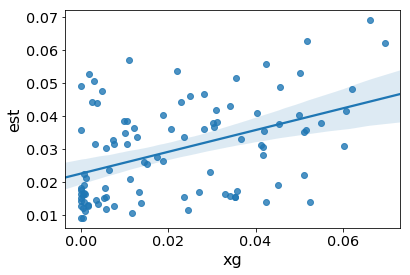

In [13]:
params = {
    'legend.fontsize': 'x-large',
    'figure.figsize': (6, 4),
    'axes.labelsize': 'x-large',
    'axes.titlesize':'x-large',
    'xtick.labelsize':'x-large',
    'ytick.labelsize':'x-large'
}
pylab.rcParams.update(params)

ax = sns.regplot(x="xg", y="est", data=cor,)
ax.set_xlabel("xg", fontsize=16)
ax.set_ylabel("est", fontsize=16)
plt.show()

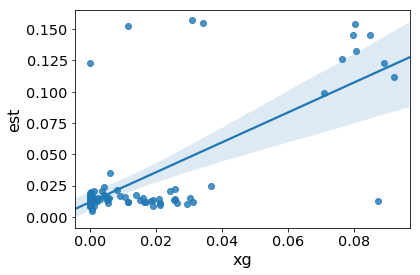

In [14]:
cor = pd.read_csv("testGammaEst_result/testGammaEst_Cor_1_example", comment="#")
cor = cor[cor.xg <=.10]
ax = sns.regplot(x="xg", y="est", data=cor,)
ax.set_xlabel("xg", fontsize=16)
ax.set_ylabel("est", fontsize=16)
plt.show()